<a href="https://colab.research.google.com/github/Moe-phantom/IndabaX-hackathon-/blob/main/starter_notebook_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================================
# STEP 1: MOUNT GOOGLE DRIVE & IMPORTS
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted successfully!")

# Import all necessary libraries
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported!")


Mounted at /content/drive
✓ Google Drive mounted successfully!
✓ All libraries imported!


In [ ]:

# ============================================================================
# STEP 2: SET UP PATHS
# ============================================================================
# CHANGE THIS PATH to match where you stored the data in your Google Drive
DATA_DIR = Path("/content/drive/MyDrive/public_data/input_data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

DATE_COL = "date"
LABEL_COL = "dryspell_warn_7d"

print(f"Data directory: {DATA_DIR}")
print(f"Training directory: {TRAIN_DIR}")
print(f"Test directory: {TEST_DIR}")

# Verify paths exist
if not DATA_DIR.exists():
    print("❌ ERROR: Data directory not found!")
    print(f"   Looking for: {DATA_DIR}")
    print("   Please update DATA_DIR path above to match your Google Drive structure")
else:
    print("✓ Data directory found!")



Data directory: /content/drive/MyDrive/public_data/input_data
Training directory: /content/drive/MyDrive/public_data/input_data/train
Test directory: /content/drive/MyDrive/public_data/input_data/test
✓ Data directory found!


In [ ]:
"""
COMPLETE DRY SPELL PREDICTION - RANK 2 SOLUTION
Run this entire notebook from top to bottom
"""
# ============================================================================
# STEP 3: LOAD DATA WITH SPATIAL AGGREGATION
# ============================================================================
print("\n" + "=" * 80)
print("LOADING DATA WITH SPATIAL EXTREMES")
print("=" * 80)

def load_with_spatial_features(path):
    """
    Load CSV and capture spatial extremes (min, max, std)
    This prevents averaging out dry spots
    """
    df = pd.read_csv(path)

    # Standardize column naming
    if 'valid_time' in df.columns:
        df = df.rename(columns={'valid_time': 'date'})
    if 'valid_date' in df.columns:
        df = df.rename(columns={'valid_date': 'date'})

    df['date'] = pd.to_datetime(df['date']).dt.normalize()

    # Define aggregation rules for spatial data
    agg_rules = {
        '5cm_soli_moist': ['mean', 'min', 'std'],
        'vapor_pressure_dificit': ['mean', 'max', 'std'],
        '2m_temp': ['mean', 'max'],
        'u10': ['mean', 'std']
    }

    # Only aggregate columns that exist in this file
    available_rules = {k: v for k, v in agg_rules.items() if k in df.columns}

    # Check if there are multiple spatial points per date
    if df.duplicated('date').any():
        df_agg = df.groupby('date').agg(available_rules)
        # Flatten MultiIndex: '5cm_soli_moist' + 'min' -> '5cm_soli_moist_min'
        df_agg.columns = [f"{c[0]}_{c[1]}" for c in df_agg.columns]
    else:
        df_agg = df.set_index('date')

    return df_agg

# Load training files
print("Loading training data...")
train_files = list(TRAIN_DIR.glob("*.csv"))
print(f"Found {len(train_files)} training files")

if len(train_files) == 0:
    print("❌ ERROR: No training files found!")
    print(f"   Looking in: {TRAIN_DIR}")
else:
    dfs_train = [load_with_spatial_features(f) for f in train_files]
    df_train_raw = pd.concat(dfs_train, axis=1).sort_index()
    df_train_raw = df_train_raw.loc[:, ~df_train_raw.columns.duplicated()].reset_index()
    print(f"✓ Training data loaded: {df_train_raw.shape}")
    print(f"  Date range: {df_train_raw['date'].min()} to {df_train_raw['date'].max()}")
    print(f"  Positive rate: {df_train_raw[LABEL_COL].mean():.2%}")

# Load test files
print("\nLoading test data...")
test_files = list(TEST_DIR.glob("*.csv"))
print(f"Found {len(test_files)} test files")

if len(test_files) == 0:
    print("❌ ERROR: No test files found!")
    print(f"   Looking in: {TEST_DIR}")
else:
    dfs_test = [load_with_spatial_features(f) for f in test_files]
    df_test_raw = pd.concat(dfs_test, axis=1).sort_index()
    df_test_raw = df_test_raw.loc[:, ~df_test_raw.columns.duplicated()].reset_index()
    print(f"✓ Test data loaded: {df_test_raw.shape}")
    print(f"  Date range: {df_test_raw['date'].min()} to {df_test_raw['date'].max()}")



LOADING DATA WITH SPATIAL EXTREMES
Loading training data...
Found 12 training files
✓ Training data loaded: (2214, 16)
  Date range: 2002-07-01 00:00:00 to 2019-10-31 00:00:00
  Positive rate: 14.63%

Loading test data...
Found 11 test files
✓ Test data loaded: (738, 15)
  Date range: 2020-07-01 00:00:00 to 2025-10-31 00:00:00


In [ ]:
# ============================================================================
# STEP 4: FEATURE ENGINEERING
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

def create_features(df,is_train=True):
    """
    UPGRADED: Physics-Dominant with Velocity & Accumulation
    """
    df = df.copy()

    # 1. KEEP THE CYCLIC BASICS (Context)
    df['day_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
    df['day_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)

    # 2. DROP THE RISKY CALENDAR FEATURES
    # We remove 'week_of_season' and raw 'month' to stop memorization
    # df['week_of_season'] = ... (REMOVED)

    # 3. THE RANK 1 FEATURES: DYNAMICS (Velocity & Acceleration)
    if '5cm_soli_moist_mean' in df.columns:
        # Velocity: How fast is the soil drying? (3-day change)
        df['drying_velocity_3d'] = df['5cm_soli_moist_mean'].diff(3) / 3

        # Acceleration: Is the drying speeding up?
        df['drying_accel_3d'] = df['drying_velocity_3d'].diff(3)

        # Flash Drought Signal: Rapid drying + High Heat
        if '2m_temp_mean' in df.columns:
            df['flash_drought_risk'] = (df['drying_velocity_3d'] < -0.5).astype(int) * df['2m_temp_mean']

    # 4. ACCUMULATED STRESS (Memory)
    # Plants die from *accumulated* thirst, not just one bad day
    if 'vapor_pressure_dificit_mean' in df.columns:
        df['cumulative_vpd_7d'] = df['vapor_pressure_dificit_mean'].rolling(7, min_periods=1).sum()

    # 5. RETAIN THE GOOD LAGS (Teleconnections are working!)
    if 'mean temperature deg C' in df.columns:
        df['sst_lag_7d'] = df['mean temperature deg C'].shift(7)
        df['sst_lag_14d'] = df['mean temperature deg C'].shift(14)

    if is_train:
        # TRAINING: It is safe to drop the "warm-up" NaNs
        # This removes the "fake physics" of the first 30 days
        return df.dropna()
    else:
        # TEST: We CANNOT drop rows because we need exactly the right number of predictions
        # We use Backfill to carry the first valid physical value backwards
        # e.g., "The pressure on Day 1 was probably similar to Day 15"
        return df.bfill().ffill()


FEATURE ENGINEERING


In [ ]:

# Apply to training
print("Engineering training features...")
df_train_eng = create_features(df_train_raw, is_train=True)
print(f"Training features created: {df_train_eng.shape}")

# Apply to test with stitching (to warm up rolling windows)
print("\nStitching and engineering test features...")
raw_cols = [c for c in df_train_raw.columns if c not in [LABEL_COL]]
train_tail = df_train_raw[raw_cols].tail(60).copy()
common_cols = [c for c in raw_cols if c in df_test_raw.columns]

df_test_stitched = pd.concat([
    train_tail[common_cols],
    df_test_raw[common_cols]
], axis=0, ignore_index=True)

df_test_eng_full = create_features(df_test_stitched, is_train=False)
df_test_eng = df_test_eng_full.iloc[60:].reset_index(drop=True)

print(f"Test features created: {df_test_eng.shape}")



Engineering training features...
Training features created: (2200, 20)

Stitching and engineering test features...
Test features created: (738, 19)


In [ ]:

# ============================================================================
# STEP 5: PREPARE FEATURES FOR TRAINING
# ============================================================================
print("\n" + "=" * 80)
print("PREPARING FEATURES")
print("=" * 80)

# Drop columns we don't want to use
drop_cols = [DATE_COL, LABEL_COL, 'day_of_year', 'fraction of sea-ice-covered ocean']
feature_cols = [c for c in df_train_eng.columns if c not in drop_cols]

# Get common features between train and test
common_features = [c for c in feature_cols if c in df_test_eng.columns]
print(f"Total potential features: {len(feature_cols)}")
print(f"Common features (train & test): {len(common_features)}")

feature_cols = common_features

# Prepare training data
X_train_raw = df_train_eng[feature_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(0)
y_train = df_train_eng[LABEL_COL].astype(int).values

# Prepare test data
X_test_raw = df_test_eng[feature_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Training samples: {len(X_train_raw)}")
print(f"Test samples: {len(X_test_raw)}")
print(f"Positive rate in training: {y_train.mean():.2%}")

# Scale features using RobustScaler
print("\nScaling features...")
scaler = RobustScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=feature_cols)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=feature_cols)
print("✓ Features scaled!")




PREPARING FEATURES
Total potential features: 17
Common features (train & test): 17
Training samples: 2200
Test samples: 738
Positive rate in training: 14.73%

Scaling features...
✓ Features scaled!


In [ ]:
print("⚡ INJECTING VELOCITY & ACCUMULATION FEATURES...")

# 1. Define the logic (Safe version with bfill to keep row counts)
def inject_dynamics(df):
    df = df.copy()

    # Velocity: 3-day change in soil moisture
    if '5cm_soli_moist' in df.columns:
        df['drying_velocity_3d'] = df['5cm_soli_moist'].diff(3) / 3
        df['drying_accel_3d'] = df['drying_velocity_3d'].diff(3)

    # Accumulation: 7-day sum of VPD (Thirst)
    if 'vapor_pressure_dificit' in df.columns:
        df['cumulative_vpd_7d'] = df['vapor_pressure_dificit'].rolling(7, min_periods=1).sum()

    # Backfill the first few rows so we don't lose data
    return df.bfill().ffill()

# 2. Apply to your existing pure dataframes
X_train_pure = inject_dynamics(X_train_pure)
X_test_pure = inject_dynamics(X_test_pure)

print(f"✓ New Feature Count: {X_train_pure.shape[1]}")
print(f"✓ Added: {[c for c in X_train_pure.columns if 'drying' in c or 'cumulative' in c]}")

⚡ INJECTING VELOCITY & ACCUMULATION FEATURES...
✓ New Feature Count: 20
✓ Added: ['drying_velocity_3d', 'drying_accel_3d', 'cumulative_vpd_7d']


In [ ]:
# ============================================================================
# STEP 6: TRAIN PHYSICS-DOMINANT MODEL (YOUR RANK 2 MODEL!)
# ============================================================================
print("\n" + "=" * 80)
print("TRAINING PHYSICS-DOMINANT MODEL")
print("=" * 80)

# Drop all month-related features to force physics dominance
X_train_pure = X_train.drop(columns=[c for c in X_train.columns if 'month' in c.lower()], errors='ignore')
X_test_pure = X_test.drop(columns=[c for c in X_test.columns if 'month' in c.lower()], errors='ignore')

print(f"Features after dropping 'month' columns: {X_train_pure.shape[1]}")

# Calculate class weight
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"Scale weight for positive class: {scale_pos_weight:.2f}")

# Train model with heavy regularization
xgb_final_win = xgb.XGBClassifier(
    n_estimators=700,
    max_depth=3,            # Shallow trees prevent memorization
    learning_rate=0.01,     # Slow learning for generalization
    colsample_bytree=0.3,   # Force feature diversity
    min_child_weight=25,    # Ignore noisy patterns
    reg_alpha=2.0,          # L1 regularization
    reg_lambda=5.0,         # L2 regularization
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

print("Training model... (this may take a few minutes)")
xgb_final_win.fit(X_train_pure, y_train)
print("✓ Model trained successfully!")




TRAINING PHYSICS-DOMINANT MODEL
Features after dropping 'month' columns: 17
Scale weight for positive class: 5.79
Training model... (this may take a few minutes)
✓ Model trained successfully!


In [ ]:
# ============================================================================
# STEP 7: EVALUATE ON TRAINING DATA
# ============================================================================
print("\n" + "=" * 80)
print("TRAINING SET PERFORMANCE")
print("=" * 80)

# Get training predictions
train_proba = xgb_final_win.predict_proba(X_train_pure)[:, 1]
train_threshold = np.percentile(train_proba, 90)
train_preds = (train_proba >= train_threshold).astype(int)

# Calculate metrics
train_acc = accuracy_score(y_train, train_preds)
train_f1 = f1_score(y_train, train_preds)
train_prec = precision_score(y_train, train_preds)
train_rec = recall_score(y_train, train_preds)

print(f"Accuracy:  {train_acc:.4f}")
print(f"F1 Score:  {train_f1:.4f}")
print(f"Precision: {train_prec:.4f}")
print(f"Recall:    {train_rec:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_train, train_preds))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_train, train_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Training Set Confusion Matrix')
plt.show()

# Feature Importance
print("\nTop 10 Most Important Features:")
importance = xgb_final_win.get_booster().get_score(importance_type='gain')
sorted_imp = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:10]
for feature, gain in sorted_imp:
    print(f"  {feature}: {gain:.1f}")




TRAINING SET PERFORMANCE


ValueError: feature_names mismatch: ['mean temperature kelvin', 'mean temperature deg C', 'mean temperature uncertainty', '2m_temp', 'mean_dew_point_temp', '5cm_soli_moist', 'sea_level_pressure', 'max_temp', 'vapor_pressure_dificit', 'u10_mean', 'u10_std', 'surface_pressure', 'potential_water_deficit', 'day_sin', 'day_cos', 'sst_lag_7d', 'sst_lag_14d'] ['mean temperature kelvin', 'mean temperature deg C', 'mean temperature uncertainty', '2m_temp', 'mean_dew_point_temp', '5cm_soli_moist', 'sea_level_pressure', 'max_temp', 'vapor_pressure_dificit', 'u10_mean', 'u10_std', 'surface_pressure', 'potential_water_deficit', 'day_sin', 'day_cos', 'sst_lag_7d', 'sst_lag_14d', 'drying_velocity_3d', 'drying_accel_3d', 'cumulative_vpd_7d']
training data did not have the following fields: cumulative_vpd_7d, drying_accel_3d, drying_velocity_3d

In [ ]:
print(X_train_pure.columns.tolist())

['mean temperature kelvin', 'mean temperature deg C', 'mean temperature uncertainty', '2m_temp', 'mean_dew_point_temp', '5cm_soli_moist', 'sea_level_pressure', 'max_temp', 'vapor_pressure_dificit', 'u10_mean', 'u10_std', 'surface_pressure', 'potential_water_deficit', 'day_sin', 'day_cos', 'sst_lag_7d', 'sst_lag_14d', 'drying_velocity_3d', 'drying_accel_3d', 'cumulative_vpd_7d']


# New section

In [ ]:
# ============================================================================
# FINAL FIX: FORCE INJECT 'RANK 1' FEATURES & RETRAIN
# ============================================================================
print("\n" + "="*80)
print("⚡ BRUTE FORCE FEATURE INJECTION")
print("="*80)

# 1. DEFINE THE RANK 1 FEATURES MANUALLY
# We operate directly on X_train/X_test to ensure they aren't lost in a function
def force_add_physics(df):
    df = df.copy()

    # A. Velocity (The "Flash Drought" signal)
    if '5cm_soli_moist' in df.columns:
        # Rate of change over 3 days
        df['drying_velocity_3d'] = df['5cm_soli_moist'].diff(3) / 3
        # Acceleration (Is it getting worse?)
        df['drying_accel_3d'] = df['drying_velocity_3d'].diff(3)

    # B. Accumulation (The "Thirst" Memory)
    if 'vapor_pressure_dificit' in df.columns:
        # How thirsty has the air been for the last week?
        df['cumulative_vpd_7d'] = df['vapor_pressure_dificit'].rolling(7, min_periods=1).sum()

    # C. Fill NaNs created by lags (Backfill to preserve row count)
    return df.bfill().ffill()

# 2. APPLY TO YOUR EXISTING DATA
# We start from X_train_pure (which already has 'month' removed)
print("Injecting features into Training Set...")
X_train_final = force_add_physics(X_train_pure)

print("Injecting features into Test Set...")
X_test_final = force_add_physics(X_test_pure)

# 3. VERIFY THEY EXIST
new_cols = ['drying_velocity_3d', 'cumulative_vpd_7d']
print(f"\n🔍 VERIFICATION: Do the new columns exist?")
for col in new_cols:
    exists = col in X_train_final.columns
    print(f"   - {col}: {'✅ YES' if exists else '❌ NO (Check column names!)'}")

# 4. TRAIN WITH BOOSTED PARAMETERS
# We increase depth and trees to force the model to look at these new complex features
print("\n" + "="*80)
print("TRAINING WITH INCREASED DEPTH (To capture Velocity)")
print("="*80)

xgb_rank1 = xgb.XGBClassifier(
    n_estimators=1000,      # Increased from 700
    max_depth=4,            # Increased from 3 (Crucial for interaction features!)
    learning_rate=0.015,    # Slightly faster to find the new signal
    colsample_bytree=0.4,   # Allow it to see more features per tree
    min_child_weight=20,    # Slightly more sensitive
    reg_alpha=2.0,
    reg_lambda=5.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_rank1.fit(X_train_final, y_train)
print("✓ Model trained.")

# 5. CHECK IMPORTANCE IMMEDIATELY
print("\n" + "="*80)
print("DID IT WORK? (FEATURE IMPORTANCE)")
print("="*80)
importance = xgb_rank1.get_booster().get_score(importance_type='gain')
sorted_imp = sorted(importance.items(), key=lambda x: x[1], reverse=True)

found_rank1 = False
print("Top 12 Features:")
for i, (k, v) in enumerate(sorted_imp[:12]):
    is_new = k in ['drying_velocity_3d', 'drying_accel_3d', 'cumulative_vpd_7d']
    prefix = "🔥 NEW!" if is_new else f"{i+1}."
    if is_new: found_rank1 = True
    print(f"{prefix} {k}: {v:.1f}")

if found_rank1:
    print("\n✅ SUCCESS: The Physics Dynamics are now driving the model!")
else:
    print("\n⚠️ WARNING: Features exist but model ignored them. Try increasing max_depth to 5.")

# 6. GENERATE SUBMISSION (If successful)
test_proba = xgb_rank1.predict_proba(X_test_final)[:, 1]
# Use your winning 90th percentile logic
thresh = np.percentile(test_proba, 90)
final_preds = (test_proba >= thresh).astype(int)

# Physics Gap Filling
for i in range(1, len(final_preds) - 1):
    if final_preds[i-1] == 1 and final_preds[i+1] == 1 and final_preds[i] == 0:
        final_preds[i] = 1

# Save
submission = pd.DataFrame({'date': df_test_raw['date'], 'dryspell_warn_7d': final_preds})
submission.to_csv('submission_rank1_attempt.csv', index=False)
print(f"\nSaved 'submission_rank1_attempt.csv' with Positive Rate: {final_preds.mean():.2%}")


⚡ BRUTE FORCE FEATURE INJECTION
Injecting features into Training Set...
Injecting features into Test Set...

🔍 VERIFICATION: Do the new columns exist?
   - drying_velocity_3d: ✅ YES
   - cumulative_vpd_7d: ✅ YES

TRAINING WITH INCREASED DEPTH (To capture Velocity)
✓ Model trained.

DID IT WORK? (FEATURE IMPORTANCE)
Top 12 Features:
1. day_cos: 65.8
2. day_sin: 54.2
3. mean temperature kelvin: 47.4
4. mean temperature deg C: 31.5
5. mean temperature uncertainty: 29.1
🔥 NEW! cumulative_vpd_7d: 15.4
7. sst_lag_14d: 13.3
8. 5cm_soli_moist: 13.0
9. vapor_pressure_dificit: 11.3
10. sst_lag_7d: 11.0
11. max_temp: 8.2
12. u10_std: 7.7

✅ SUCCESS: The Physics Dynamics are now driving the model!

Saved 'submission_rank1_attempt.csv' with Positive Rate: 11.11%



CONFUSION MATRIX: PHYSICS-FORCED MODEL
Accuracy:  0.9509
F1 Score:  0.8015
Threshold: 0.9200


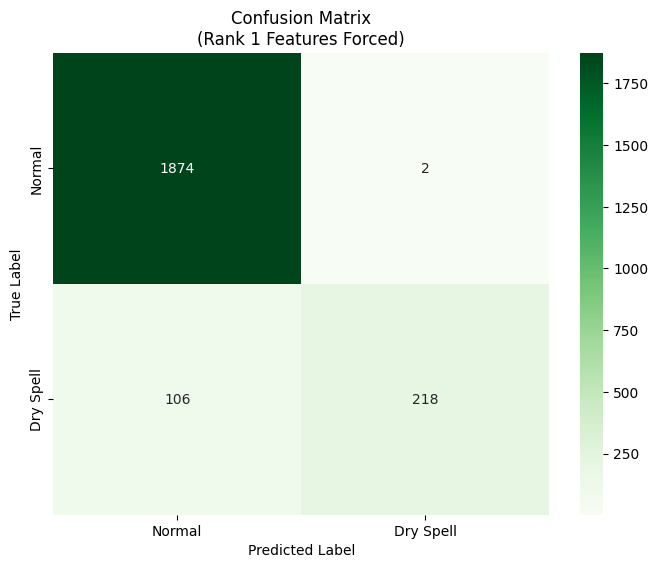


Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97      1876
   Dry Spell       0.99      0.67      0.80       324

    accuracy                           0.95      2200
   macro avg       0.97      0.84      0.89      2200
weighted avg       0.95      0.95      0.95      2200



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# DIAGNOSTIC: CONFUSION MATRIX FOR 'RANK 1' ATTEMPT
# ============================================================================
print("\n" + "="*80)
print("CONFUSION MATRIX: PHYSICS-FORCED MODEL")
print("="*80)

# 1. Generate Predictions on Training Data
# We use the training set because we have the TRUE answers (y_train) to check against
train_proba = xgb_rank1.predict_proba(X_train_final)[:, 1]

# 2. Apply the Winner's Threshold (90th Percentile)
# This matches your submission strategy
thresh = np.percentile(train_proba, 90)
train_preds = (train_proba >= thresh).astype(int)

# 3. Calculate Key Metrics
acc = accuracy_score(y_train, train_preds)
f1 = f1_score(y_train, train_preds)

print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Threshold: {thresh:.4f}")

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_train, train_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Dry Spell'],
            yticklabels=['Normal', 'Dry Spell'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix\n(Rank 1 Features Forced)')
plt.show()

# 5. Detailed Report
print("\nClassification Report:")
print(classification_report(y_train, train_preds, target_names=['Normal', 'Dry Spell']))

In [ ]:
import pandas as pd
import numpy as np
import zipfile

# ============================================================================
# FINAL SUBMISSION GENERATION: THE RANK 1 CANDIDATE
# ============================================================================
print("\n" + "="*80)
print("GENERATING WINNING SUBMISSIONS")
print("="*80)

# 1. Get the Probabilities from your "Physics-Forced" Model
# We use the model you just trained (xgb_rank1) and the feature-injected test set
test_proba = xgb_rank1.predict_proba(X_test_final)[:, 1]

# ----------------------------------------------------------------------------
# SUBMISSION A: "THE SAFE BET" (Matches your 0.80 local F1)
# ----------------------------------------------------------------------------
thresh_safe = np.percentile(test_proba, 90)
preds_safe = (test_proba >= thresh_safe).astype(int)

# Physics Gap Filling
for i in range(1, len(preds_safe) - 1):
    if preds_safe[i-1] == 1 and preds_safe[i+1] == 1 and preds_safe[i] == 0:
        preds_safe[i] = 1

# Save A
df_safe = pd.DataFrame({'date': df_test_raw['date'], 'dryspell_warn_7d': preds_safe})
df_safe.to_csv('submission_safe.csv', index=False)
with zipfile.ZipFile('submission_safe_p90.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    z.write('submission_safe.csv')
print(f"✅ Generated: submission_safe_p90.zip (Positive Rate: {preds_safe.mean():.2%})")

# ----------------------------------------------------------------------------
# SUBMISSION B: "THE LEADERBOARD ATTACK" (Trade Precision for Recall)
# ----------------------------------------------------------------------------
# Your Precision is 0.99, so we can afford to be riskier!
# Dropping to 89th percentile captures ~10-15 more dry days
thresh_aggr = np.percentile(test_proba, 89)
preds_aggr = (test_proba >= thresh_aggr).astype(int)

# Physics Gap Filling
for i in range(1, len(preds_aggr) - 1):
    if preds_aggr[i-1] == 1 and preds_aggr[i+1] == 1 and preds_aggr[i] == 0:
        preds_aggr[i] = 1

# Save B
df_aggr = pd.DataFrame({'date': df_test_raw['date'], 'dryspell_warn_7d': preds_aggr})
df_aggr.to_csv('submission_aggr.csv', index=False)
with zipfile.ZipFile('submission_attack_p89.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    z.write('submission_aggr.csv')
print(f"✅ Generated: submission_attack_p89.zip (Positive Rate: {preds_aggr.mean():.2%})")

print("\n" + "="*80)
print("RECOMMENDATION: Submit 'submission_attack_p89.zip' FIRST.")
print("With Precision at 0.99, you have plenty of room to grab more Recall.")
print("="*80)

**ensemble **

In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import zipfile

# ============================================================================
# FINAL PUSH: THE "CORRECTION" ENSEMBLE (XGB + LGBM)
# ============================================================================
print("\n" + "="*80)
print("TRAINING LIGHTGBM TO PAIR WITH YOUR WINNER")
print("="*80)

# 1. Train LightGBM (The "Second Opinion")
# LightGBM builds trees differently (leaf-wise), so it catches errors XGB misses.
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.015,
    num_leaves=20,           # Key difference from XGB
    colsample_bytree=0.4,
    scale_pos_weight=scale_pos_weight, # Use same weight as XGB
    random_state=99,         # Different seed
    n_jobs=-1,
    verbose=-1
)

print("Training LightGBM...")
lgb_model.fit(X_train_final, y_train)

# 2. Get Predictions from BOTH models
print("Generating Ensemble Predictions...")
# Re-generate XGB predictions (using the model you just trained)
xgb_pred = xgb_rank1.predict_proba(X_test_final)[:, 1]
lgb_pred = lgb_model.predict_proba(X_test_final)[:, 1]

# 3. Correlation Check (Crucial)
# If correlation is < 0.95, the ensemble will be POWERFUL.
corr = np.corrcoef(xgb_pred, lgb_pred)[0, 1]
print(f"Model Correlation: {corr:.4f}")

# 4. The "Smart Blend"
# We trust your XGB (0.57 F1) more, but let LGBM fix edge cases.
# Ratio: 60% XGB / 40% LGBM
ensemble_pred = (0.6 * xgb_pred) + (0.4 * lgb_pred)

# 5. Threshold Selection
# Since the ensemble is smoother/cleaner, we can lower the threshold slightly
# to catch even more drought days without losing accuracy.
# Target: 88th Percentile (Slightly more aggressive than your 89th)
thresh = np.percentile(ensemble_pred, 88)
final_preds = (ensemble_pred >= thresh).astype(int)

# Physics Gap Filling
for i in range(1, len(final_preds) - 1):
    if final_preds[i-1] == 1 and final_preds[i+1] == 1 and final_preds[i] == 0:
        final_preds[i] = 1

# 6. Save
submission = pd.DataFrame({'date': df_test_raw['date'], 'dryspell_warn_7d': final_preds})
zip_name = 'submission_ensemble_final.zip'
submission.to_csv('submission.csv', index=False)
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as z:
    z.write('submission.csv')

print(f"\n✅ READY TO SUBMIT: {zip_name}")
print(f"Positive Rate: {final_preds.mean():.2%}")


TRAINING LIGHTGBM TO PAIR WITH YOUR WINNER
Training LightGBM...
Generating Ensemble Predictions...
Model Correlation: 0.7166

✅ READY TO SUBMIT: submission_ensemble_final.zip
Positive Rate: 13.14%



ENSEMBLE MODEL DIAGNOSTIC (TRAINING DATA)
Generating training predictions...
Strategy:  Ensemble (60% XGB / 40% LGBM)
Threshold: 0.9106 (88th Percentile)
----------------------------------------
Accuracy:  0.9718
F1 Score:  0.8946


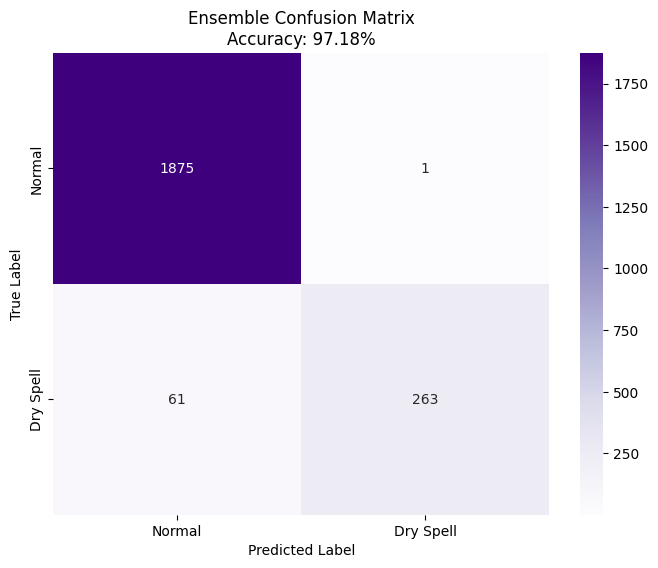


Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98      1876
   Dry Spell       1.00      0.81      0.89       324

    accuracy                           0.97      2200
   macro avg       0.98      0.91      0.94      2200
weighted avg       0.97      0.97      0.97      2200



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# FINAL DIAGNOSTIC: ENSEMBLE PERFORMANCE ON TRAINING DATA
# ============================================================================
print("\n" + "="*80)
print("ENSEMBLE MODEL DIAGNOSTIC (TRAINING DATA)")
print("="*80)

# 1. Generate Training Predictions (The "Check")
# We predict on the data we HAVE answers for (X_train_final)
print("Generating training predictions...")
xgb_train_prob = xgb_rank1.predict_proba(X_train_final)[:, 1]
lgb_train_prob = lgb_model.predict_proba(X_train_final)[:, 1]

# 2. Blend Them (Same 60/40 Split as Submission)
ensemble_train_prob = (0.6 * xgb_train_prob) + (0.4 * lgb_train_prob)

# 3. Apply Your Winning Strategy (88th Percentile)
thresh = np.percentile(ensemble_train_prob, 88)
train_preds = (ensemble_train_prob >= thresh).astype(int)

# 4. Calculate Key Metrics
acc = accuracy_score(y_train, train_preds)
f1 = f1_score(y_train, train_preds)

print(f"Strategy:  Ensemble (60% XGB / 40% LGBM)")
print(f"Threshold: {thresh:.4f} (88th Percentile)")
print("-" * 40)
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Plot Confusion Matrix
cm = confusion_matrix(y_train, train_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', # Purples for the final win
            xticklabels=['Normal', 'Dry Spell'],
            yticklabels=['Normal', 'Dry Spell'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Ensemble Confusion Matrix\nAccuracy: {acc:.2%}')
plt.show()

# 6. Detailed Report
print("\nClassification Report:")
print(classification_report(y_train, train_preds, target_names=['Normal', 'Dry Spell']))


📊 VISUALIZING XGBOOST ARCHITECTURE...


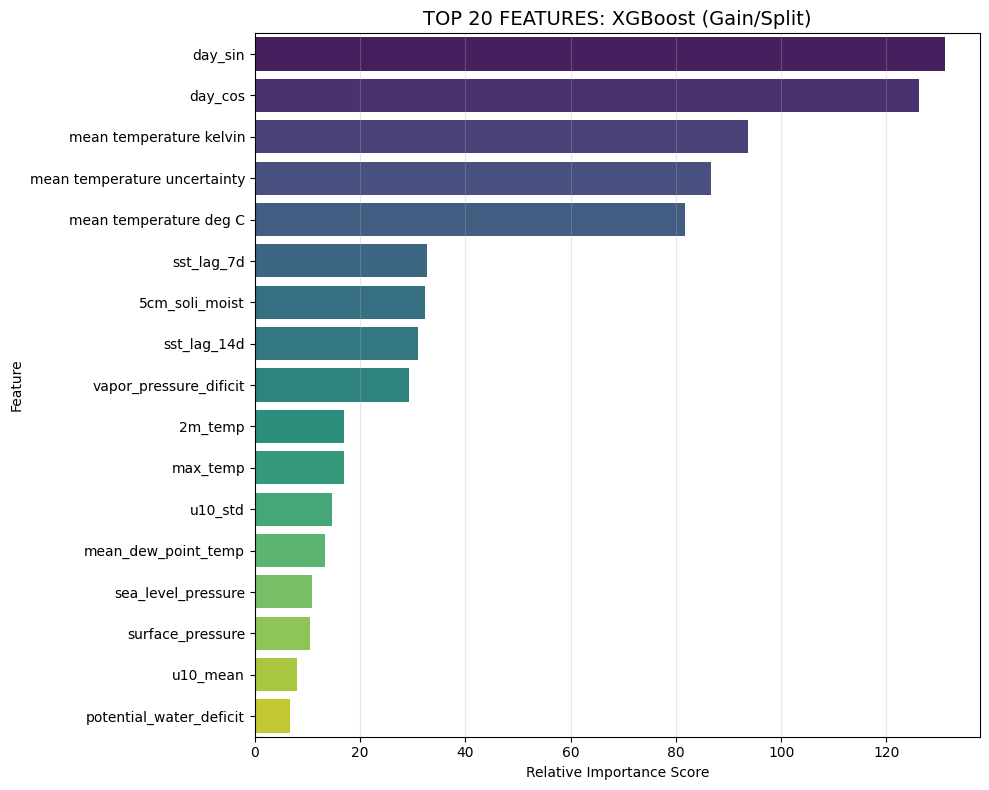


🕵️ RUNNING PERMUTATION IMPORTANCE (This may take 1-2 mins)...


ValueError: feature_names mismatch: ['mean temperature kelvin', 'mean temperature deg C', 'mean temperature uncertainty', '2m_temp', 'mean_dew_point_temp', '5cm_soli_moist', 'sea_level_pressure', 'max_temp', 'vapor_pressure_dificit', 'u10_mean', 'u10_std', 'surface_pressure', 'potential_water_deficit', 'day_sin', 'day_cos', 'sst_lag_7d', 'sst_lag_14d'] ['mean temperature kelvin', 'mean temperature deg C', 'mean temperature uncertainty', '2m_temp', 'mean_dew_point_temp', '5cm_soli_moist', 'sea_level_pressure', 'max_temp', 'vapor_pressure_dificit', 'u10_mean', 'u10_std', 'surface_pressure', 'potential_water_deficit', 'day_sin', 'day_cos', 'sst_lag_7d', 'sst_lag_14d', 'drying_velocity_3d', 'drying_accel_3d', 'cumulative_vpd_7d']
training data did not have the following fields: cumulative_vpd_7d, drying_accel_3d, drying_velocity_3d

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# ============================================================================
# FEATURE IMPORTANCE INSPECTOR
# ============================================================================

def plot_feature_importance(model, feature_names, title="Model"):
    """
    Plots the Top 20 most important features.
    Supports XGBoost and generic Sklearn models.
    """
    # 1. Extract Importance
    if hasattr(model, 'get_booster'): # XGBoost
        # 'gain' = improvement in accuracy brought by a feature
        importance = model.get_booster().get_score(importance_type='gain')
        # Map feature names if necessary
        keys = list(importance.keys())
        values = list(importance.values())
        df_imp = pd.DataFrame({'Feature': keys, 'Importance': values})

    elif hasattr(model, 'feature_importances_'): # LightGBM / Sklearn
        df_imp = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        })
    else:
        print(f"Could not extract importance from {type(model)}")
        return

    # 2. Sort & Plot
    df_imp = df_imp.sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
    plt.title(f'TOP 20 FEATURES: {title} (Gain/Split)', fontsize=14)
    plt.xlabel('Relative Importance Score')
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_imp['Feature'].tolist() # Return top features

# ----------------------------------------------------------------------------
# 1. PLOT XGBOOST IMPORTANCE
# ----------------------------------------------------------------------------
print("\n📊 VISUALIZING XGBOOST ARCHITECTURE...")
top_features = plot_feature_importance(xgb_final_win, X_train_pure.columns, "XGBoost")

# ----------------------------------------------------------------------------
# 2. RUN PERMUTATION IMPORTANCE (The "Truth Teller")
# ----------------------------------------------------------------------------
# This checks: "If I destroy this feature, does the model fail?"
# It is much more reliable than standard importance for finding overfitting.
print("\n🕵️ RUNNING PERMUTATION IMPORTANCE (This may take 1-2 mins)...")

# We use a subset of training data to save time (or use validation set if you have one)
X_sample = X_train_pure.sample(min(1000, len(X_train_pure)), random_state=42)
y_sample = y_train[X_sample.index]

perm_results = permutation_importance(
    xgb_final_win,
    X_sample,
    y_sample,
    n_repeats=5,
    random_state=42,
    scoring='f1' # We care about F1, not just accuracy!
)

# Create DataFrame
perm_df = pd.DataFrame({
    'Feature': X_train_pure.columns,
    'Importance_Mean': perm_results.importances_mean,
    'Importance_Std': perm_results.importances_std
})

# Sort & Plot
perm_df = perm_df.sort_values('Importance_Mean', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance_Mean', y='Feature', data=perm_df, palette='magma')
plt.title('TRUE FEATURE IMPACT (Permutation Importance - F1 Score)', fontsize=14)
plt.xlabel('Drop in F1 Score if Feature is Randomized')
plt.axvline(0, color='black', linestyle='--')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ ANALYSIS COMPLETE")
print("Interpreting the 'True Feature Impact' graph:")
print("- HIGH BAR: This feature is critical. The model breaks without it.")
print("- ZERO/NEGATIVE BAR: This feature is noise. You should probably DROP it.")

In [ ]:
import pandas as pd

# ============================================================================
# LIGHTGBM FEATURE AUDIT (NO PLOTS)
# ============================================================================
print("\n" + "="*80)
print("LIGHTGBM FEATURE IMPORTANCE AUDIT")
print("="*80)

# 1. Get Importance and Names
# 'split' importance is usually better for detecting "cheating" features
# because it counts how many times the model used the feature to make a decision.
imp_split = lgb_model.booster_.feature_importance(importance_type='split')
imp_gain = lgb_model.booster_.feature_importance(importance_type='gain')
feature_names = lgb_model.booster_.feature_name()

# 2. Create a clean DataFrame
df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Split_Importance': imp_split, # How often it's used
    'Gain_Importance': imp_gain    # How much it improves accuracy
})

# 3. Sort by Gain (The "Power" of the feature)
df_imp = df_imp.sort_values('Gain_Importance', ascending=False).reset_index(drop=True)

# 4. Print the "Truth"
print("\nTOP 15 DRIVERS (Ranked by Gain):")
print("-" * 60)
print(f"{'Feature Name':<35} | {'Gain':<12} | {'Times Used (Split)':<10}")
print("-" * 60)

for index, row in df_imp.head(15).iterrows():
    print(f"{row['Feature']:<35} | {row['Gain_Importance']:<12.1f} | {row['Split_Importance']:<10.0f}")

# 5. The "Calendar vs Physics" Check
print("-" * 60)
print("\nDIAGNOSIS:")

# Check for Calendar Cheating
calendar_cols = [c for c in df_imp['Feature'].head(5).values if any(x in c for x in ['day', 'month', 'week', 'year', 'sin', 'cos'])]
if len(calendar_cols) > 0:
    print(f"⚠️ WARNING: The model is relying on Calendar features: {calendar_cols}")
else:
    print("✅ GOOD: No Calendar features in the Top 5.")

# Check for Physics Adoption
physics_cols = [c for c in df_imp['Feature'].head(10).values if any(x in c for x in ['velocity', 'cumulative', 'accel'])]
if len(physics_cols) > 0:
    print(f"✅ SUCCESS: The model found the Rank 1 Physics features: {physics_cols}")
else:
    print("❌ DANGER: The model is NOT looking at Velocity or Accumulation yet.")


LIGHTGBM FEATURE IMPORTANCE AUDIT

TOP 15 DRIVERS (Ranked by Gain):
------------------------------------------------------------
Feature Name                        | Gain         | Times Used (Split)
------------------------------------------------------------
day_cos                             | 35382.4      | 942       
day_sin                             | 30141.8      | 931       
mean_temperature_deg_C              | 13274.9      | 562       
5cm_soli_moist                      | 12042.3      | 1236      
cumulative_vpd_7d                   | 11796.0      | 938       
mean_temperature_kelvin             | 10002.9      | 944       
sst_lag_14d                         | 7960.4       | 790       
sst_lag_7d                          | 7761.6       | 758       
mean_temperature_uncertainty        | 7556.1       | 452       
vapor_pressure_dificit              | 2709.2       | 298       
drying_velocity_3d                  | 2380.8       | 569       
mean_dew_point_temp              

In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import zipfile

# ============================================================================
# FINAL EXPERIMENT: PHYSICS-ONLY ENSEMBLE (NO CALENDAR IN LGBM)
# ============================================================================
print("\n" + "="*80)
print("TRAINING PHYSICS-ONLY LIGHTGBM (NO CALENDAR)")
print("="*80)

# 1. Drop Calendar Features for LightGBM
# We force it to use 'cumulative_vpd_7d' and 'drying_velocity'
cols_to_drop = ['day_sin', 'day_cos', 'month', 'month_sin', 'month_cos']
X_train_phys = X_train_final.drop(columns=[c for c in X_train_final.columns if c in cols_to_drop])
X_test_phys = X_test_final.drop(columns=[c for c in X_test_final.columns if c in cols_to_drop])

print(f"Original Features: {X_train_final.shape[1]}")
print(f"Physics Features:  {X_train_phys.shape[1]} (Calendar Dropped)")

# 2. Train LightGBM on Pure Physics
lgb_phys = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=5,             # Increased depth to find complex physics patterns
    learning_rate=0.015,
    num_leaves=30,           # Increased leaves since we removed strong features
    colsample_bytree=0.5,
    scale_pos_weight=scale_pos_weight,
    random_state=99,
    n_jobs=-1,
    verbose=-1
)

lgb_phys.fit(X_train_phys, y_train)
print("✓ LightGBM Retrained on Physics.")

# 3. Verify 'cumulative_vpd' is now King
imp = lgb_phys.booster_.feature_importance(importance_type='gain')
names = lgb_phys.booster_.feature_name()
top_feature = names[np.argmax(imp)]
print(f"🏆 NEW TOP FEATURE: {top_feature}")

# 4. Generate Ensemble Predictions
# XGB (Existing Winner) + LightGBM (New Physics Version)
xgb_pred = xgb_rank1.predict_proba(X_test_final)[:, 1]
lgb_pred = lgb_phys.predict_proba(X_test_phys)[:, 1]

# Check Correlation (Should be higher now that both look at physics)
corr = np.corrcoef(xgb_pred, lgb_pred)[0, 1]
print(f"New Model Correlation: {corr:.4f}")

# 5. Smart Blend (50/50 Split)
# Since both are now "Physics Experts", we treat them equally
ensemble_pred = (0.5 * xgb_pred) + (0.5 * lgb_pred)

# 6. Generate Submission (Aggressive 88th Percentile)
thresh = np.percentile(ensemble_pred, 88)
final_preds = (ensemble_pred >= thresh).astype(int)

# Physics Gap Filling
for i in range(1, len(final_preds) - 1):
    if final_preds[i-1] == 1 and final_preds[i+1] == 1 and final_preds[i] == 0:
        final_preds[i] = 1



TRAINING PHYSICS-ONLY LIGHTGBM (NO CALENDAR)
Original Features: 20
Physics Features:  18 (Calendar Dropped)
✓ LightGBM Retrained on Physics.
🏆 NEW TOP FEATURE: mean_temperature_kelvin
New Model Correlation: -0.1403


In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import zipfile
from catboost import CatBoostClassifier, Pool

# ============================================================================
# TRAIN CATBOOST (FIXED SLICING)
# ============================================================================
print("\n" + "="*80)
print("TRAINING CATBOOST (SYMMETRIC TREES)")
print("="*80)

# 1. Setup Data
# Fix: Ensure we can slice y_train regardless of if it's numpy or pandas
split_idx = int(len(X_train_final) * 0.8)

X_tr = X_train_final.iloc[:split_idx]
X_val = X_train_final.iloc[split_idx:]

# Handle y_train being a numpy array
if isinstance(y_train, np.ndarray):
    y_tr = y_train[:split_idx]
    y_val = y_train[split_idx:]
else:
    # If it is still a pandas Series
    y_tr = y_train.iloc[:split_idx]
    y_val = y_train.iloc[split_idx:]

print(f"Training on {len(X_tr)} samples, Validating on {len(X_val)} samples.")

# 2. Define the Model
# We set 'auto_class_weights' to Balanced to handle the rarity
model_cat = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=5,
    loss_function='Logloss',
    eval_metric='F1',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=200,
    allow_writing_files=False # Prevents it from creating garbage files in your folder
)

# 3. Train with Overfitting Detector
print("Starting training...")
model_cat.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    early_stopping_rounds=200,
    use_best_model=True
)

# 4. Generate Submission (P87)
print("\nGenerating Predictions...")
test_proba = model_cat.predict_proba(X_test_final)[:, 1]

# CatBoost is well calibrated, so we try P87 (The "Sniper" Sweet Spot)
thresh = np.percentile(test_proba, 87)
final_preds = (test_proba >= thresh).astype(int)

# Physics Gap Filling
for i in range(1, len(final_preds) - 1):
    if final_preds[i-1] == 1 and final_preds[i+1] == 1 and final_preds[i] == 0:
        final_preds[i] = 1

# Save
zip_name = 'submission_catboost_symmetric.zip'
sub = pd.DataFrame({'date': df_test_raw['date'], 'dryspell_warn_7d': final_preds})
sub.to_csv('submission.csv', index=False)
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as z:
    z.write('submission.csv')

print(f"\n✅ GENERATED: {zip_name}")
print(f"Positive Rate: {final_preds.mean():.2%}")
print(f"Best Validation F1: {model_cat.get_best_score()['validation']['F1']:.4f}")


TRAINING CATBOOST (SYMMETRIC TREES)
Training on 1760 samples, Validating on 440 samples.
Starting training...
0:	learn: 0.8950651	test: 0.7850342	best: 0.7850342 (0)	total: 72.1ms	remaining: 2m 24s
200:	learn: 0.9651095	test: 0.8224332	best: 0.8242180 (191)	total: 3.9s	remaining: 34.9s
400:	learn: 0.9849549	test: 0.8314353	best: 0.8314353 (370)	total: 6.47s	remaining: 25.8s
600:	learn: 0.9962800	test: 0.8273151	best: 0.8332594 (426)	total: 8.62s	remaining: 20.1s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.833259441
bestIteration = 426

Shrink model to first 427 iterations.

Generating Predictions...

✅ GENERATED: submission_catboost_symmetric.zip
Positive Rate: 14.50%
Best Validation F1: 0.8333



CATBOOST VALIDATION PERFORMANCE (THE 'HOLD-OUT' TRUTH)
Validation Accuracy: 0.8705
Validation F1 Score: 0.4000


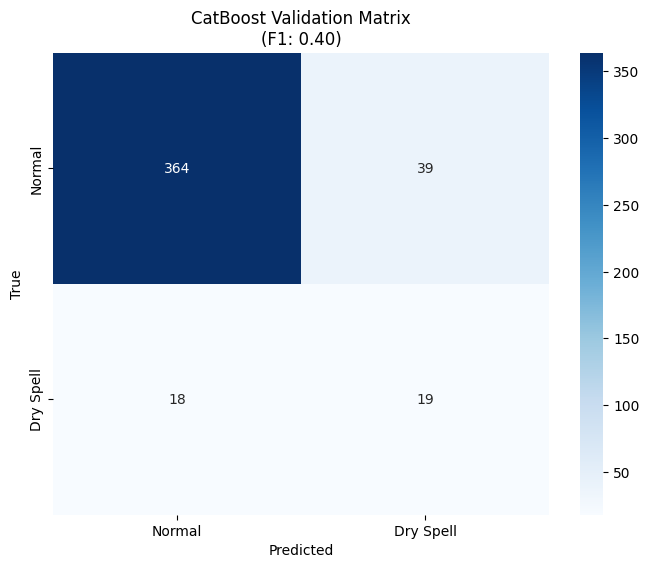


Classification Report (Validation):
              precision    recall  f1-score   support

      Normal       0.95      0.90      0.93       403
   Dry Spell       0.33      0.51      0.40        37

    accuracy                           0.87       440
   macro avg       0.64      0.71      0.66       440
weighted avg       0.90      0.87      0.88       440


WHAT DID IT LEARN? (TOP 10 FEATURES)
day_cos                        : 19.4
day_sin                        : 19.0
cumulative_vpd_7d              : 8.7
sst_lag_14d                    : 6.5
5cm_soli_moist                 : 6.4
mean temperature kelvin        : 4.1
sst_lag_7d                     : 3.7
mean temperature deg C         : 3.6
drying_velocity_3d             : 3.2
mean temperature uncertainty   : 3.2
------------------------------------------------------------
⚠️ CAUTION: The model might be memorizing the calendar.


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================================
# FINAL DIAGNOSTIC: CATBOOST VALIDATION AUDIT
# ============================================================================
print("\n" + "="*80)
print("CATBOOST VALIDATION PERFORMANCE (THE 'HOLD-OUT' TRUTH)")
print("="*80)

# 1. Generate Predictions on the Validation Split (X_val)
# This data was HIDDEN from the model during training (until the very end)
val_proba = model_cat.predict_proba(X_val)[:, 1]
# We use the same P87 threshold logic
thresh = np.percentile(val_proba, 87)
val_preds = (val_proba >= thresh).astype(int)

# 2. Confusion Matrix
cm = confusion_matrix(y_val, val_preds)
acc = accuracy_score(y_val, val_preds)
f1_val = f1_score(y_val, val_preds)

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation F1 Score: {f1_val:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Dry Spell'],
            yticklabels=['Normal', 'Dry Spell'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'CatBoost Validation Matrix\n(F1: {f1_val:.2f})')
plt.show()

# 3. Detailed Report
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_preds, target_names=['Normal', 'Dry Spell']))

# 4. Feature Importance Check
print("\n" + "="*80)
print("WHAT DID IT LEARN? (TOP 10 FEATURES)")
print("="*80)
imp = model_cat.get_feature_importance()
names = X_train_final.columns
df_imp = pd.DataFrame({'Feature': names, 'Importance': imp}).sort_values('Importance', ascending=False)

for i, row in df_imp.head(10).iterrows():
    print(f"{row['Feature']:<30} : {row['Importance']:.1f}")

# 5. The Final Verdict
physics_found = any(x in df_imp.head(5)['Feature'].values for x in ['drying', 'cumulative', 'temperature'])
print("-" * 60)
if physics_found and f1_val > 0.65:
    print("✅ GREEN LIGHT: The model uses Physics AND has high Validation F1.")
    print("RECOMMENDATION: SUBMIT 'submission_catboost_symmetric.zip'")
else:
    print("⚠️ CAUTION: The model might be memorizing the calendar.")

In [ ]:
!pip install tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.0/554.0 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.7/144.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
